# Kết quả Cross-Validation — So sánh các Method

Notebook này **chỉ đọc lại** các file CSV đã được `python -m toxic_comments` lưu sẵn trong thư mục `results/` — không train lại bất kỳ model nào, kể cả `roberta_label_dependency`. Chạy lại notebook này bao nhiêu lần cũng không tốn thời gian/GPU.

File kết quả được ghi **tăng dần theo từng fold**, nên có thể chạy notebook này ngay cả khi terminal khác vẫn đang train — số liệu sẽ phản ánh đúng những fold đã hoàn thành.

**Yêu cầu:** đã chạy ít nhất một fold của
```
python -m toxic_comments --include-transformers --folds 5
```
và có 2 file trong `results/`: `cross_validation_results.csv`, `summary_results.csv`.

In [7]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Cùng quy ước với các notebook khác trong repo: nếu đang chạy từ notebooks/
# thì repo root là thư mục cha, ngược lại lấy thư mục hiện tại.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Nếu bạn chạy CLI với --output khác mặc định, sửa lại dòng dưới cho khớp.
RESULTS_DIR = PROJECT_ROOT / "results"

FOLD_RESULTS_PATH = RESULTS_DIR / "cross_validation_results.csv"
SUMMARY_PATH = RESULTS_DIR / "summary_results.csv"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("RESULTS_DIR  =", RESULTS_DIR)
print("fold results exists:", FOLD_RESULTS_PATH.exists())
print("summary exists:     ", SUMMARY_PATH.exists())

PROJECT_ROOT = /root/Seminar2
RESULTS_DIR  = /root/Seminar2/results
fold results exists: True
summary exists:      True


## 1. Load dữ liệu đã lưu

Nếu ô dưới báo lỗi `FileNotFoundError`: nghĩa là quá trình train ở bước CLI chưa chạy xong (experiment.py chỉ ghi 2 file này **sau khi tất cả model, tất cả fold đều xong**), hoặc `RESULTS_DIR` ở trên đang trỏ sai thư mục — kiểm tra lại đường dẫn `--output` bạn đã dùng khi chạy CLI.

In [8]:
if not FOLD_RESULTS_PATH.exists() or not SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"Chưa thấy kết quả trong {RESULTS_DIR}. "
        "Chạy xong `python -m toxic_comments --include-transformers` trước, "
        "rồi quay lại chạy notebook này."
    )

fold_results = pd.read_csv(FOLD_RESULTS_PATH)
# summary_results.csv có 2 tầng cột (metric, mean/std) — cần header=[0, 1] để đọc đúng
summary = pd.read_csv(SUMMARY_PATH, header=[0, 1], index_col=0)

print("Các model có trong kết quả:", fold_results['model_name'].unique().tolist())
print("Số fold mỗi model:")
print(fold_results.groupby('model_name')['fold'].count())

Các model có trong kết quả: ['dummy_most_frequent', 'tfidf_logistic_regression', 'roberta_label_dependency']
Số fold mỗi model:
model_name
dummy_most_frequent          5
roberta_label_dependency     5
tfidf_logistic_regression    5
Name: fold, dtype: int64


## 2. Bảng tổng hợp (mean ± std qua các fold)

Sắp xếp theo **macro-F1** giảm dần — đây là metric chính theo research design (macro-F1 coi trọng các label thiểu số như `threat`, `identity_hate` ngang với `toxic`).

In [9]:
KEY_METRICS = ["macro_f1", "micro_f1", "subset_accuracy", "hamming_loss", "micro_roc_auc"]

def format_mean_std(frame: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    """Gộp (mean, std) thành một chuỗi 'mean ± std' dễ đọc cho từng metric."""
    formatted = pd.DataFrame(index=frame.index)
    for metric in metrics:
        if metric not in frame.columns.get_level_values(0):
            continue
        mean = frame[(metric, "mean")]
        std = frame[(metric, "std")]
        formatted[metric] = [f"{m:.4f} ± {s:.4f}" for m, s in zip(mean, std)]
    return formatted

summary_display = format_mean_std(summary, KEY_METRICS)
summary_display = summary_display.reindex(
    summary[("macro_f1", "mean")].sort_values(ascending=False).index
)
summary_display

,macro_f1,micro_f1,subset_accuracy,hamming_loss,micro_roc_auc
model_name,,,,,
tfidf_logistic_regression,0.5924 ± 0.0034,0.7071 ± 0.0023,0.8922 ± 0.0016,0.0253 ± 0.0004,0.9832 ± 0.0009
roberta_label_dependency,0.5661 ± 0.0473,0.7752 ± 0.0045,0.9241 ± 0.0034,0.0163 ± 0.0009,0.9912 ± 0.0008
dummy_most_frequent,0.0000 ± 0.0000,0.0000 ± 0.0000,0.8982 ± 0.0024,0.0367 ± 0.0010,0.5000 ± 0.0000


## 3. Biểu đồ so sánh Macro-F1 giữa các model

Cột càng cao càng tốt; thanh lỗi (error bar) là độ lệch chuẩn giữa các fold — thanh lỗi dài nghĩa là kết quả chưa ổn định qua các fold, nên cẩn thận khi kết luận.

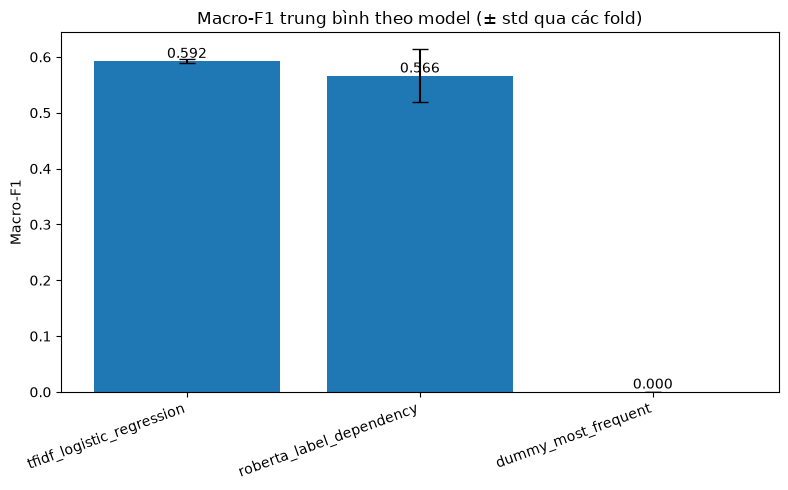

In [10]:
macro_f1_mean = summary[("macro_f1", "mean")].sort_values(ascending=False)
macro_f1_std = summary[("macro_f1", "std")].reindex(macro_f1_mean.index)

fig, ax = plt.subplots(figsize=(8, 5))
x_positions = np.arange(len(macro_f1_mean))
bars = ax.bar(x_positions, macro_f1_mean.values, yerr=macro_f1_std.values, capsize=6)
ax.set_ylabel("Macro-F1")
ax.set_title("Macro-F1 trung bình theo model (± std qua các fold)")
ax.set_xticks(x_positions)
ax.set_xticklabels(macro_f1_mean.index, rotation=20, ha="right")
for bar, value in zip(bars, macro_f1_mean.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{value:.3f}",
            ha="center", va="bottom")
fig.tight_layout()
fig.savefig(RESULTS_DIR / "macro_f1_comparison.png", dpi=150)
plt.show()

## 4. Biến thiên qua từng fold (boxplot)

Nhìn độ phân tán thật của macro-F1 qua 5 fold, thay vì chỉ một con số trung bình.

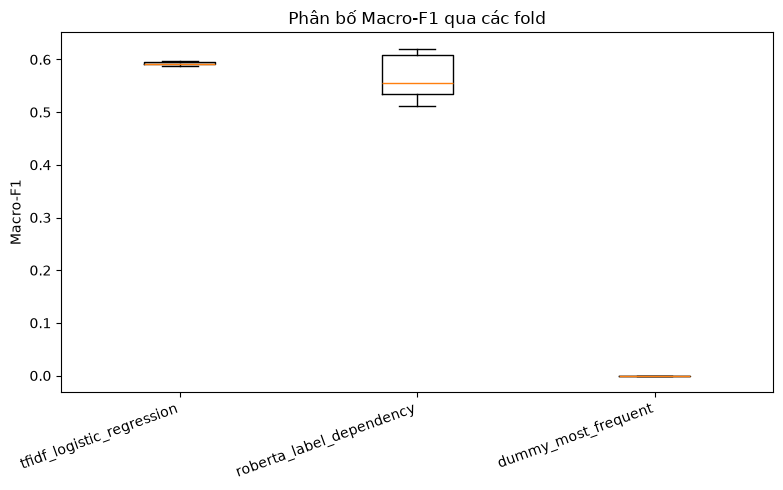

In [11]:
model_order = macro_f1_mean.index.tolist()
data_by_model = [
    fold_results.loc[fold_results["model_name"] == model, "macro_f1"].values
    for model in model_order
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_by_model, tick_labels=model_order)
ax.set_ylabel("Macro-F1")
ax.set_title("Phân bố Macro-F1 qua các fold")
ax.set_xticks(range(1, len(model_order) + 1))
ax.set_xticklabels(model_order, rotation=20, ha="right")
fig.tight_layout()
plt.show()

## 5. Bảng chi tiết theo từng fold

Hữu ích khi cần trích số cụ thể vào báo cáo LaTeX, hoặc kiểm tra xem có fold nào bất thường (ví dụ RoBERTa hội tụ kém ở một fold cụ thể do dữ liệu fold đó ít mẫu nhãn hiếm).

In [12]:
pivot = fold_results.pivot(index="fold", columns="model_name", values="macro_f1")
pivot.style.format("{:.4f}").background_gradient(axis=1, cmap="Greens")

model_name,dummy_most_frequent,roberta_label_dependency,tfidf_logistic_regression
fold,,,
1,0.0000,0.5118,0.5880
2,0.0000,0.6093,0.5952
3,0.0000,0.5339,0.5963
4,0.0000,0.6205,0.5912
5,0.0000,0.5550,0.5911


## Ghi chú / giới hạn

- **Giờ xem được tiến độ giữa chừng**: `experiment.py` đã được cập nhật để ghi `cross_validation_results.csv` và `summary_results.csv` ngay sau **mỗi fold**, không chỉ khi toàn bộ chạy xong. Có thể chạy lại notebook này bất cứ lúc nào trong khi RoBERTa còn đang train ở terminal khác — số liệu sẽ phản ánh đúng những fold đã xong.
- `evaluation.py` hiện chỉ tính metric **micro/macro tổng hợp**, chưa có breakdown theo từng nhãn (`threat`, `identity_hate`, ...). Muốn phân tích minority-label theo đúng phần *Evaluation Strategy* trong research design (PR-AUC/F1 riêng từng nhãn), cần bổ sung per-label metrics vào `evaluate_predictions` — hỏi mình nếu muốn làm phần đó.

push